# GGM Plots

In [1]:
import numpy as np
import os
import torch 
import torch.distributions as dists
from matplotlib import pyplot as plt
from scipy import stats
import sys
# Add parent directory of this file to path
sys.path.append(os.path.dirname(os.path.abspath('')))
from MSM.utils.data import get_ci
from HPC.GGM import experiment_utils as ex_utils

plt.rc('font',**{'family':'sans-serif'})
#If fonttype = 1 doesn't work with LaTeX, try fonttype 42.
plt.rc('pdf',fonttype = 42)
plt.rc('ps',fonttype = 42)
plt.rcParams['figure.dpi'] = 140

def AUC(tprs, fprs):
    return torch.trapz(tprs, fprs, dim=-1)

# Vary Missingness

## Star Prec

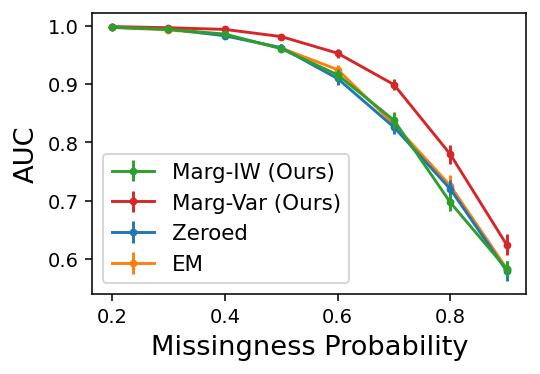

In [3]:
save_path = os.path.join(
    os.path.pardir, "simulated_data", "GGM", "50Dim_StarPrec", "VaryMiss"
)
methods = ["iw", "variational", "missdiff", "em"]
labels = ["Marg-IW (Ours)", "Marg-Var (Ours)", "Zeroed", "EM"]
colours = ["C2", "C3", "C0", "C1"]
fig, ax = plt.subplots(figsize=(4, 2.6))
missprobs = torch.arange(0.2, 0.91, 0.1)
ypos = 1
for i,method in enumerate(methods):
    results = []
    results_quantile = []
    for missprob in missprobs:
        stored_vals = torch.load(
            os.path.join(
                save_path, f"{method}_fullauc_repeat_missprob_{missprob:.1f}.pth"
            ),
            weights_only=True,
        )
        # For each element of stored_vals["TPR"] extend to length 120 by adding 1s to the end
        sub_tprs = torch.stack([torch.cat((tpr, torch.ones(120-tpr.shape[0]))) for tpr in stored_vals["TPR"]])
        sub_fprs = torch.stack([torch.cat((fpr, torch.ones(120-fpr.shape[0]))) for fpr in stored_vals["FPR"]])
        
        sub_tprs = torch.cat(
            (torch.zeros(sub_fprs.shape[0], 1), sub_tprs, torch.ones(sub_fprs.shape[0], 1)), dim=1
        )
        sub_fprs = torch.cat(
            (torch.zeros(sub_fprs.shape[0], 1), sub_fprs, torch.ones(sub_fprs.shape[0], 1)), dim=1
        )
        aucs = AUC(sub_tprs, sub_fprs)
        results.append(get_ci(aucs, dim=0))
        results_quantile.append(torch.quantile(aucs, q=torch.tensor([0.5,0.25,0.75]), dim=0))


    results = torch.stack(results,dim=-1)
    results_quantile = torch.stack(results_quantile,dim=-1)

    ax.errorbar(missprobs, results[0], results[2] - results[0],
                fmt="o-", label=labels[i], markersize=3, color=colours[i], zorder=5-i)
ax.legend(fontsize=11)
ax.set_xlabel("Missingness Probability", fontsize=14)
ax.set_ylabel("AUC", fontsize=14)
fig.savefig("../plots/GGM/GGM_50_StarPrec_VaryMiss_AUC.pdf", bbox_inches="tight")

### Single AUC

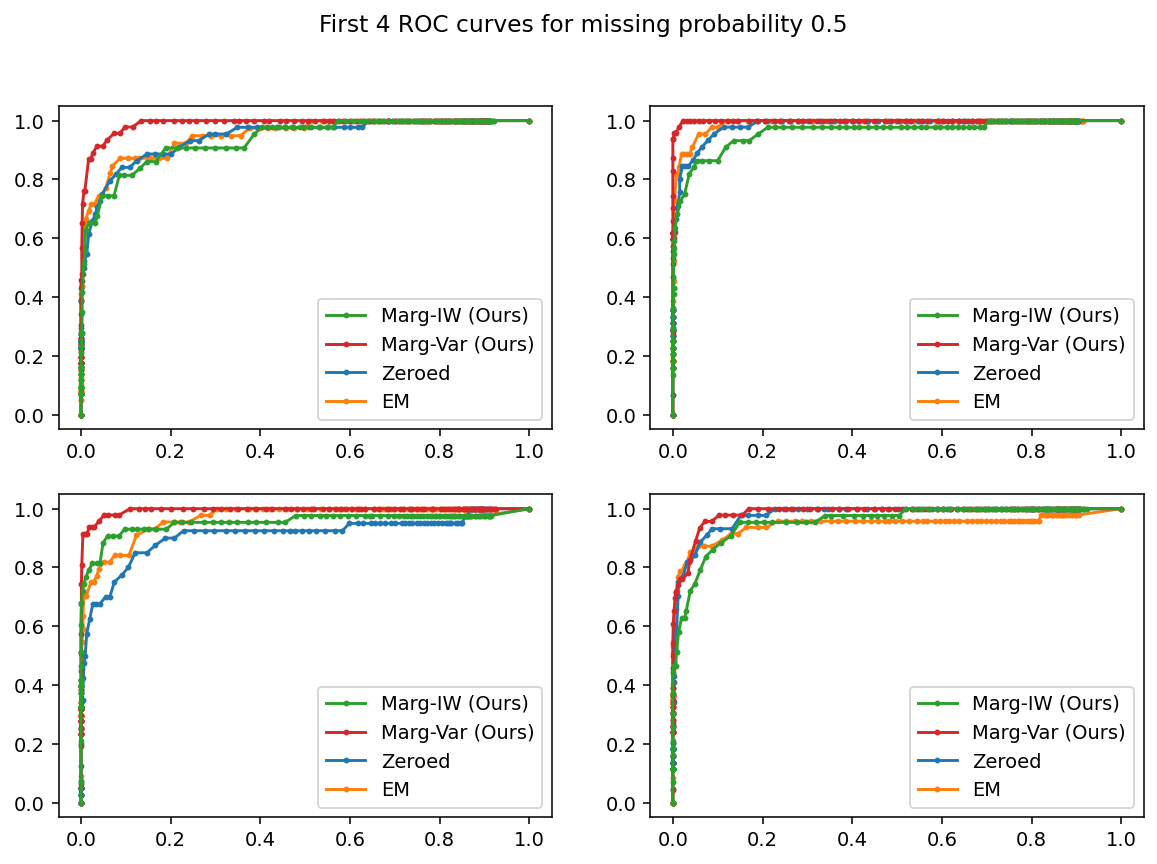

In [4]:
save_path = os.path.join(
    os.path.pardir, "simulated_data", "GGM", "50Dim_StarPrec", "VaryMiss"
)
methods = ["iw", "variational", "missdiff", "em"]
labels = ["Marg-IW (Ours)", "Marg-Var (Ours)", "Zeroed", "EM"]
colours = ["C2", "C3", "C0", "C1"]
fig, ax = plt.subplots(figsize=(10, 6.6), nrows=2, ncols=2)
missprob = 0.5
missprob_ind = 3
ypos = 1
for k in range(4):
    for i,method in enumerate(methods):
        results = []
        results_quantile = []

        stored_vals = torch.load(
            os.path.join(
                save_path, f"{method}_fullauc_repeat_missprob_{missprob:.1f}.pth"
            ),
            weights_only=True,
        )
        # For each element of stored_vals["TPR"] extend to length 120 by adding 1s to the end
        sub_tprs = torch.stack([torch.cat((tpr, torch.ones(120-tpr.shape[0]))) for tpr in stored_vals["TPR"]])
        sub_fprs = torch.stack([torch.cat((fpr, torch.ones(120-fpr.shape[0]))) for fpr in stored_vals["FPR"]])
        
        sub_tprs = torch.cat(
            (torch.zeros(sub_fprs.shape[0], 1), sub_tprs, torch.ones(sub_fprs.shape[0], 1)), dim=1
        )
        sub_fprs = torch.cat(
            (torch.zeros(sub_fprs.shape[0], 1), sub_fprs, torch.ones(sub_fprs.shape[0], 1)), dim=1
        )
        
        ax.flatten()[k].plot(sub_fprs[k], sub_tprs[k], label=labels[i], linestyle="-", marker="o", markersize=2, color=colours[i], zorder=5-i)
        ax.flatten()[k].legend()
fig.suptitle(f"First 4 ROC curves for missing probability 0.5")
fig.savefig("../plots/GGM/GGM_50_StarPrec_VaryMiss_ROC.pdf", bbox_inches="tight")

### Accuracy

44.1


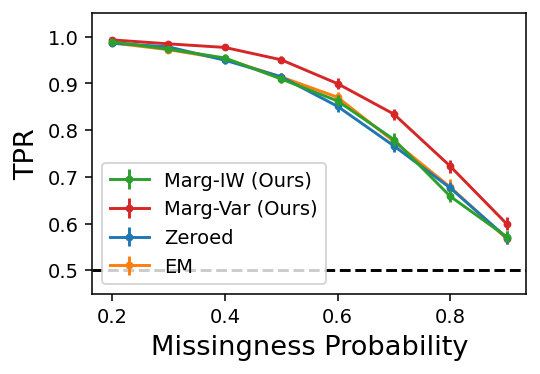

In [5]:
### Accuracy
save_path = os.path.join(
    os.path.pardir, "simulated_data", "GGM", "50Dim_StarPrec", "VaryMiss"
)
methods = ["iw", "variational", "missdiff", "em"]
labels = ["Marg-IW (Ours)", "Marg-Var (Ours)", "Zeroed", "EM"]
colours = ["C2", "C3", "C0", "C1"]
fig, ax = plt.subplots(figsize=(4, 2.6))
missprobs = torch.arange(0.2, 0.91, 0.1)
dim = 50
prob_connected = 0.9
n_connected = (dim-1)*prob_connected
print(n_connected)
n_edge = dim*(dim-1)/2
ypos = 1
for i,method in enumerate(methods):
    results = []
    results_quantile = []
    for missprob in missprobs:
        stored_vals = torch.load(
            os.path.join(
                save_path, f"{method}_fullauc_repeat_missprob_{missprob:.1f}.pth"
            ),
            weights_only=True,
        )
        # For each element of stored_vals["TPR"] extend to length 120 by adding 1s to the end
        sub_tprs = torch.stack([torch.cat((tpr, torch.ones(120-tpr.shape[0]))) for tpr in stored_vals["TPR"]])
        sub_fprs = torch.stack([torch.cat((fpr, torch.ones(120-fpr.shape[0]))) for fpr in stored_vals["FPR"]])
        
        sub_tprs = torch.cat(
            (torch.zeros(sub_fprs.shape[0], 1), sub_tprs, torch.ones(sub_fprs.shape[0], 1)), dim=1
        )
        sub_fprs = torch.cat(
            (torch.zeros(sub_fprs.shape[0], 1), sub_fprs, torch.ones(sub_fprs.shape[0], 1)), dim=1
        )
        tps = sub_tprs*n_connected
        fps = sub_fprs*n_connected
        pos = tps+fps
        # Over the 2nd index find the first case where pos>n_connected
        change_points = torch.argmax((pos>n_connected).float(), dim=1)
        # print(change_points)
        sub_tprs = sub_tprs[torch.arange(sub_tprs.shape[0]), change_points]
        sub_fprs = sub_fprs[torch.arange(sub_fprs.shape[0]), change_points]
#         aucs = AUC(sub_tprs, sub_fprs)
        results.append(get_ci(sub_tprs, dim=0))
        results_quantile.append(torch.quantile(sub_tprs, q=torch.tensor([0.5,0.25,0.75]), dim=0))


    results = torch.stack(results,dim=-1)
    results_quantile = torch.stack(results_quantile,dim=-1)

    ax.errorbar(missprobs, results[0], results[2] - results[0],
                fmt="o-", label=labels[i], markersize=3, color=colours[i], zorder=5-i)
ax.set_ylim(0.45, 1.05)
ax.axhline(0.5, linestyle="--", color="black")
ax.legend()
ax.set_xlabel("Missingness Probability", fontsize=14)
ax.set_ylabel("TPR", fontsize=14)
fig.savefig("../plots/GGM/GGM_50_StarPrec_VaryMiss_TPR.pdf", bbox_inches="tight")

## One Block

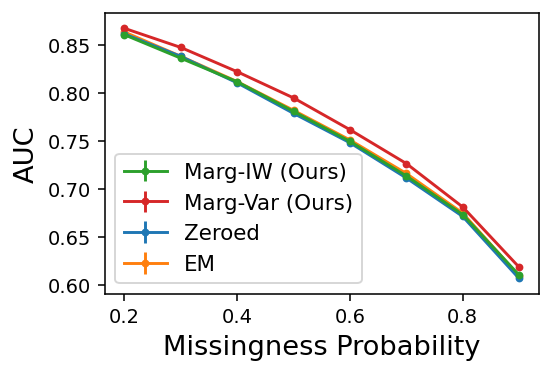

In [7]:
save_path = os.path.join(
    os.path.pardir, "simulated_data", "GGM", "100Dim_OneBlock", "VaryMiss"
)
methods = ["iw", "variational", "missdiff", "em"]
labels = ["Marg-IW (Ours)", "Marg-Var (Ours)", "Zeroed", "EM"]
colours = ["C2", "C3", "C0", "C1"]
fig, ax = plt.subplots(figsize=(4, 2.6))
missprobs = torch.arange(0.2, 0.91, 0.1)
ypos = 1
for i, method in enumerate(methods):
    results = []
    results_quantile = []
    for missprob in missprobs:
        stored_vals = torch.load(
            os.path.join(
                save_path, f"{method}_fullauc_repeat_missprob_{missprob:.1f}.pth"
            ),
            weights_only=True,
        )
        # For each element of stored_vals["TPR"] extend to length 120 by adding 1s to the end
        sub_tprs = torch.stack([torch.cat((tpr, torch.ones(120-tpr.shape[0]))) for tpr in stored_vals["TPR"]])
        sub_fprs = torch.stack([torch.cat((fpr, torch.ones(120-fpr.shape[0]))) for fpr in stored_vals["FPR"]])
        
        sub_tprs = torch.cat(
            (torch.zeros(sub_fprs.shape[0], 1), sub_tprs, torch.ones(sub_fprs.shape[0], 1)), dim=1
        )
        sub_fprs = torch.cat(
            (torch.zeros(sub_fprs.shape[0], 1), sub_fprs, torch.ones(sub_fprs.shape[0], 1)), dim=1
        )
        aucs = AUC(sub_tprs, sub_fprs)
        results.append(get_ci(aucs, dim=0))
        results_quantile.append(torch.quantile(aucs, q=torch.tensor([0.5,0.25,0.75]), dim=0))


    results = torch.stack(results,dim=-1)
    results_quantile = torch.stack(results_quantile,dim=-1)

    ax.errorbar(missprobs, results[0], results[2] - results[0], fmt="o-",
                label=labels[i], markersize=3, color=colours[i], zorder=5-i)
ax.legend(fontsize=11) 
ax.set_xlabel("Missingness Probability", fontsize=14)
ax.set_ylabel("AUC", fontsize=14)
fig.savefig("../plots/GGM/GGM_100_OneBlock_VaryMiss_AUC.pdf", bbox_inches="tight")

# Vary Centres

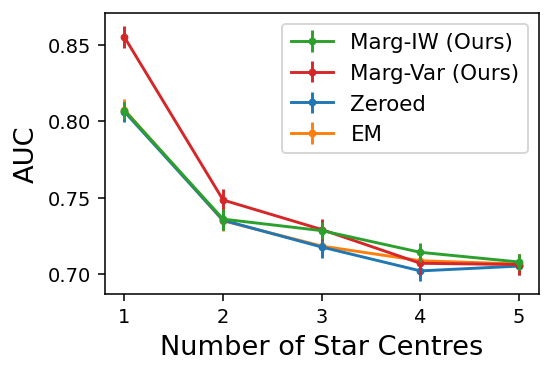

In [9]:
save_path = os.path.join(
    os.path.pardir, "simulated_data", "GGM", "100Dim_StarPrec", "VaryCentres"
)
methods = ["iw", "variational", "missdiff", "em"]
names = ["Marg-IW (Ours)",  "Marg-Var (Ours)", "Zeroed", "EM"]
colors = ["C2", "C3", "C0", "C1"]
fig, ax = plt.subplots(1, 1, figsize=(4, 2.6))
num_centres = [1,2,3,4,5]
ypos = 1
for i, method in enumerate(methods):
    results = []
    results_quantile = []
    for ncentres in num_centres:
        stored_vals = torch.load(
            os.path.join(
                save_path, f"{method}_fullauc_repeat_ncentres_{ncentres}.pth"
            ),
            weights_only=True,
        )
        # For each element of stored_vals["TPR"] extend to length 120 by adding 1s to the end
        sub_tprs = torch.stack([torch.cat((tpr, torch.ones(120-tpr.shape[0]))) for tpr in stored_vals["TPR"]])
        sub_fprs = torch.stack([torch.cat((fpr, torch.ones(120-fpr.shape[0]))) for fpr in stored_vals["FPR"]])
        
        sub_tprs = torch.cat(
            (torch.zeros(sub_fprs.shape[0], 1), sub_tprs, torch.ones(sub_fprs.shape[0], 1)), dim=1
        )
        sub_fprs = torch.cat(
            (torch.zeros(sub_fprs.shape[0], 1), sub_fprs, torch.ones(sub_fprs.shape[0], 1)), dim=1
        )
        aucs = AUC(sub_tprs, sub_fprs)
        results.append(get_ci(aucs, dim=0))
        results_quantile.append(torch.quantile(aucs, q=torch.tensor([0.5,0.25,0.75]), dim=0))


    results = torch.stack(results,dim=-1)
    results_quantile = torch.stack(results_quantile,dim=-1)

    ax.errorbar(num_centres, results[0], results[2] - results[0],
                fmt="o-", label=names[i], color=colors[i], markersize=3, zorder=5-i)
    
# Make ax tick points display as integers
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels([1, 2, 3, 4, 5])
# ax.set_ylim(0.4, .8)
# ax.axhline(0.5, linestyle="--", color="red")
ax.legend(loc="upper right", fontsize=11)
ax.set_xlabel("Number of Star Centres", fontsize=14)
ax.set_ylabel("AUC", fontsize=14)
fig.savefig("../plots/GGM/GGM_100_StarPrec_VaryCentres_AUC.pdf", bbox_inches="tight")

# Vary Dimension

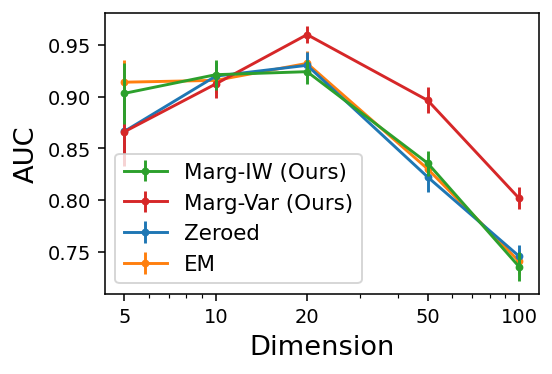

In [10]:
save_path = os.path.join(
    os.path.pardir, "simulated_data", "GGM", "StarPrec", "VaryDim"
)
methods = ["iw", "variational", "missdiff", "em"]
names = ["Marg-IW (Ours)",  "Marg-Var (Ours)", "Zeroed", "EM"]
colors = ["C2", "C3", "C0", "C1"]
fig, ax = plt.subplots(1, 1, figsize=(4, 2.6))
dims = [5, 10, 20, 50, 100]
ypos = 1
for i, method in enumerate(methods):
    results = []
    results_quantile = []
    for dim in dims:
        stored_vals = torch.load(
            os.path.join(
                save_path, f"{method}_fullauc_repeat_dim_{dim}.pth"
            ),
            weights_only=True,
        )
        # For each element of stored_vals["TPR"] extend to length 120 by adding 1s to the end
        sub_tprs = torch.stack([torch.cat((tpr, torch.ones(120-tpr.shape[0]))) for tpr in stored_vals["TPR"]])
        sub_fprs = torch.stack([torch.cat((fpr, torch.ones(120-fpr.shape[0]))) for fpr in stored_vals["FPR"]])
        
        sub_tprs = torch.cat(
            (torch.zeros(sub_fprs.shape[0], 1), sub_tprs, torch.ones(sub_fprs.shape[0], 1)), dim=1
        )
        sub_fprs = torch.cat(
            (torch.zeros(sub_fprs.shape[0], 1), sub_fprs, torch.ones(sub_fprs.shape[0], 1)), dim=1
        )
        aucs = AUC(sub_tprs, sub_fprs)
        results.append(get_ci(aucs, dim=0))
        results_quantile.append(torch.quantile(aucs, q=torch.tensor([0.5,0.25,0.75]), dim=0))


    results = torch.stack(results,dim=-1)
    results_quantile = torch.stack(results_quantile,dim=-1)

    ax.errorbar(dims, results[0], results[2] - results[0],
                fmt="o-", label=names[i], color=colors[i], markersize=3, zorder=5-i)

# ax.set_ylim(0.4, .8)
ax.legend(loc="lower left",fontsize=11)
ax.set_xlabel("Dimension", fontsize=14)
ax.set_xscale("log")
ax.set_ylabel("AUC", fontsize=14)
ax.set_xticks(dims)
ax.set_xticklabels(dims)
fig.savefig("../plots/GGM/GGM_StarPrec_VaryDim_AUC.pdf", bbox_inches="tight")

# Plot marginalisations

## 1 Centre

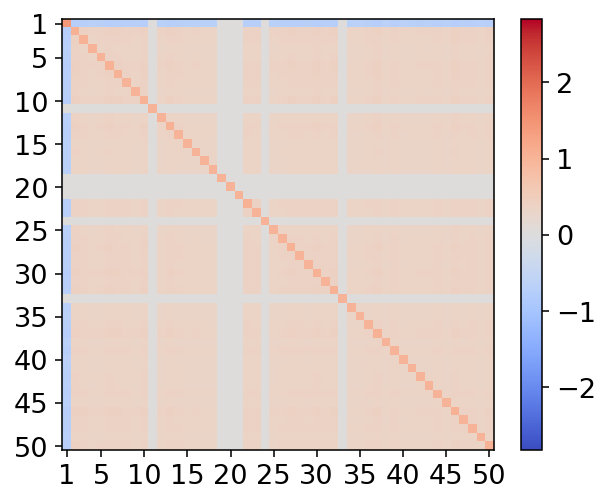

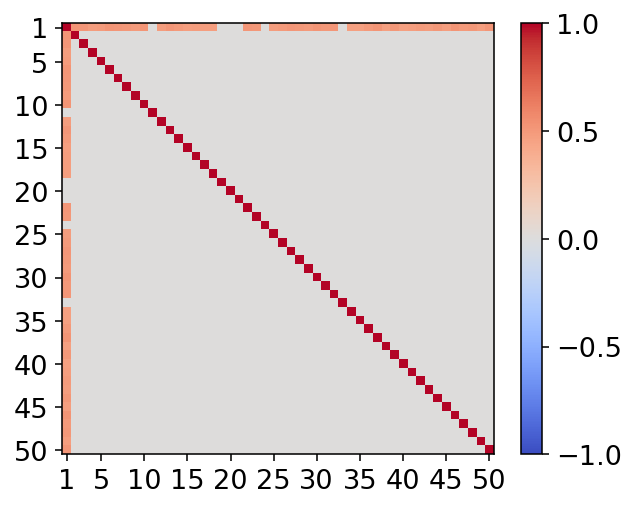

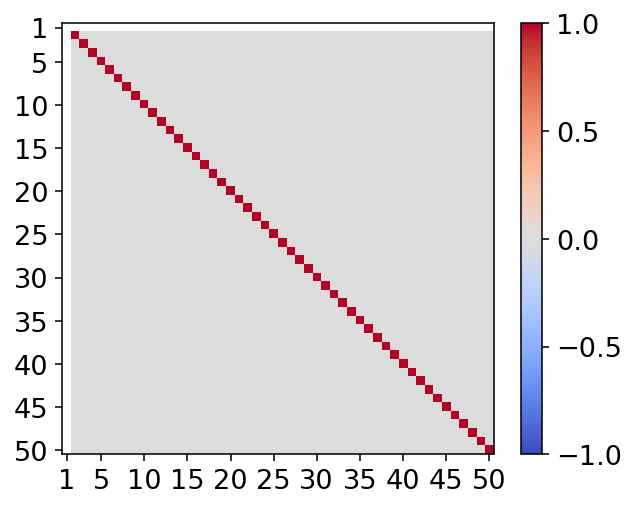

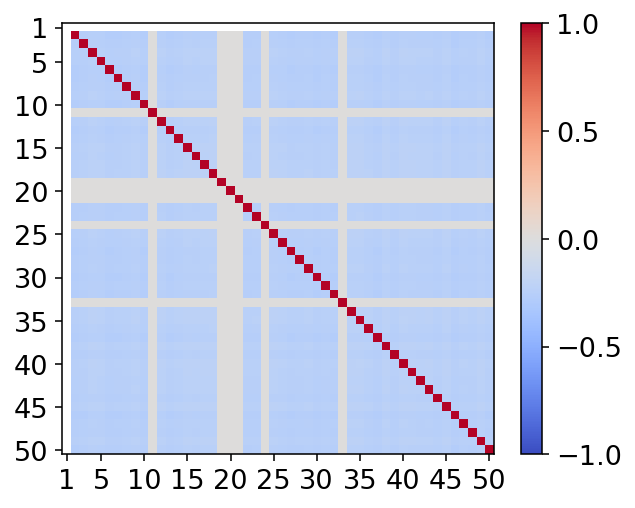

In [11]:
torch.manual_seed(3)
dim = 50
prob_connected = 0.8
min_eval = 0.1
prec = ex_utils.make_star_prec(dim, prob_connected)
cov = torch.inverse(prec)
cov_squish = np.cbrt(cov.numpy())
prec_squish = np.cbrt(prec.numpy())
subset_inds = torch.ones(dim).bool()
subset_inds[0] = False

naive_marge = torch.nan*torch.ones(dim,dim)
true_marge = torch.nan*torch.ones(dim,dim)
# Get "fake" marginal precision by just subsetting precision matrix
naive_marge[1:,:][:, 1:] = prec[subset_inds][:, subset_inds]
# Get true marginal precision by inverting the fake marginal precision
true_marge[1:,:][:, 1:] = torch.inverse(torch.inverse(prec)[subset_inds][:, subset_inds])
naive_marge_squish = np.cbrt(naive_marge.numpy())
true_marg_squish = np.cbrt(true_marge.numpy())
vlim = np.nanmax(np.abs(np.concatenate((naive_marge_squish.flatten(),true_marg_squish.flatten()))))

fig, ax = plt.subplots(figsize=(5, 4))
cax0 = ax.imshow(cov_squish, cmap='coolwarm', vmin=-np.max(np.abs(cov.numpy())), vmax=np.max(np.abs(cov.numpy())))
ax.set_xticks(np.concatenate((np.array([0]),np.arange(4,true_marg_squish.shape[0], 5))))
ax.set_yticks(np.concatenate((np.array([0]),np.arange(4,true_marg_squish.shape[0], 5))))
ax.set_xticklabels(np.concatenate((np.array([1]), np.arange(5, cov.shape[0] + 1, 5))), fontsize=14)
ax.set_yticklabels(np.concatenate((np.array([1]), np.arange(5, cov.shape[0] + 1, 5))), fontsize=14)
fig.colorbar(cax0, ax=ax).ax.tick_params(labelsize=14)
fig.savefig("../plots/GGM/StarCovariance.pdf")

fig, ax = plt.subplots(figsize=(5, 4))
cax1 = ax.imshow(prec_squish, cmap='coolwarm', vmin=-np.max(np.abs(prec.numpy())), vmax=np.max(np.abs(prec.numpy())))
fig.colorbar(cax1, ax=ax).ax.tick_params(labelsize=14)
ax.set_xticks(np.concatenate((np.array([0]),np.arange(4,true_marg_squish.shape[0], 5))))
ax.set_yticks(np.concatenate((np.array([0]),np.arange(4,true_marg_squish.shape[0], 5))))
ax.set_xticklabels(np.concatenate((np.array([1]), np.arange(5, cov.shape[0] + 1, 5))), fontsize=14)
ax.set_yticklabels(np.concatenate((np.array([1]), np.arange(5, cov.shape[0] + 1, 5))), fontsize=14)
fig.savefig("../plots/GGM/StarPrecision.pdf")


# Plot both kinds of marginalisation
fig, ax = plt.subplots(figsize=(5, 4))
cax0 = ax.imshow(naive_marge_squish, cmap='coolwarm', vmin=-vlim, vmax=vlim)
fig.colorbar(cax0, ax=ax).ax.tick_params(labelsize=14)
ax.set_xticks(np.concatenate((np.array([0]),np.arange(4,true_marg_squish.shape[0], 5))))
ax.set_yticks(np.concatenate((np.array([0]),np.arange(4,true_marg_squish.shape[0], 5))))
ax.set_xticklabels(np.concatenate((np.array([1]), np.arange(5, cov.shape[0] + 1, 5))), fontsize=14)
ax.set_yticklabels(np.concatenate((np.array([1]), np.arange(5, cov.shape[0] + 1, 5))), fontsize=14)
fig.savefig("../plots/GGM/StarPrecNaiveMarginalisation.pdf")

fig, ax = plt.subplots(figsize=(5, 4))
cax1 = ax.imshow(true_marg_squish, cmap='coolwarm', vmin=-vlim, vmax=vlim)
fig.colorbar(cax1, ax=ax).ax.tick_params(labelsize=14)
ax.set_xticks(np.concatenate((np.array([0]),np.arange(4,true_marg_squish.shape[0], 5))))
ax.set_yticks(np.concatenate((np.array([0]),np.arange(4,true_marg_squish.shape[0], 5))))
ax.set_xticklabels(np.concatenate((np.array([1]), np.arange(5, cov.shape[0] + 1, 5))), fontsize=14)
ax.set_yticklabels(np.concatenate((np.array([1]), np.arange(5, cov.shape[0] + 1, 5))), fontsize=14)
fig.savefig("../plots/GGM/StarPrecTrueMarginalisation.pdf")

## 5 Centres

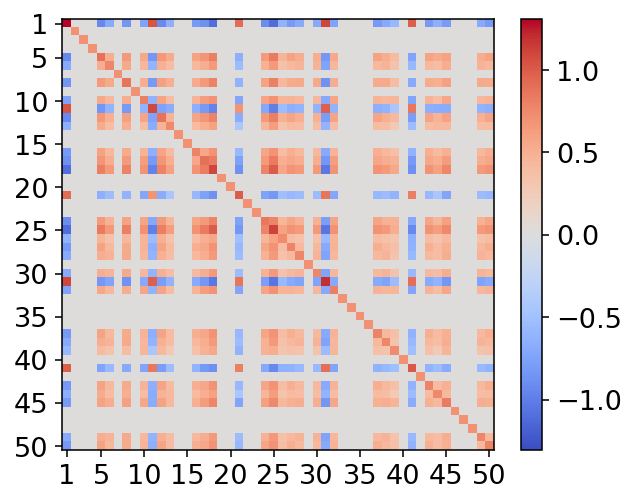

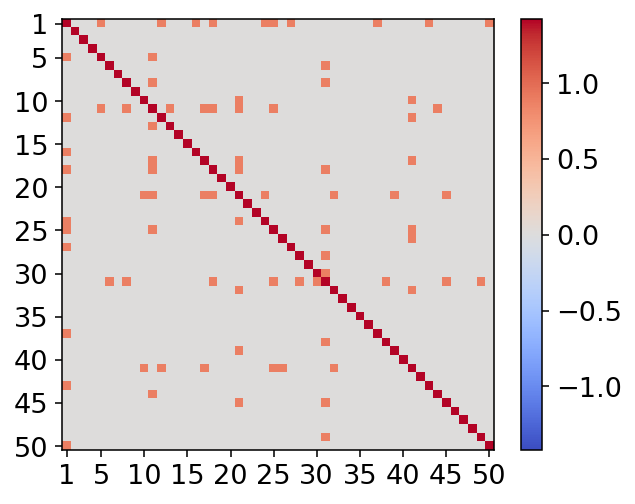

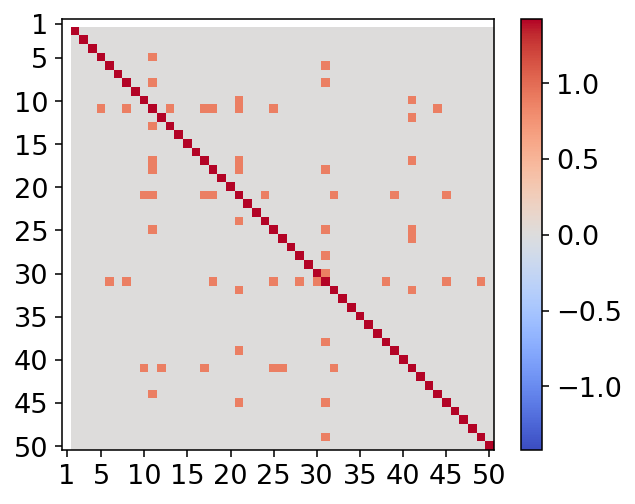

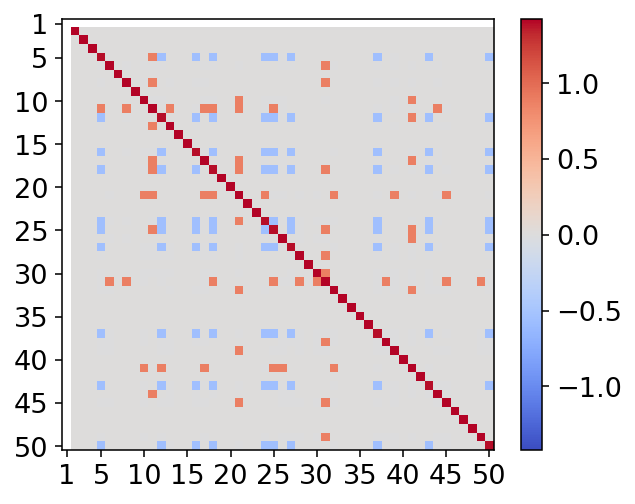

In [12]:
dim = 50
prob_connected = 0.8/5
min_eval = 0.1
prec = ex_utils.make_multistar_fixed_prec(dim, prob_connected,min_eval=0.1, num_stars=5)

prec[[1,2,3,4,10,20,30,40]]=prec[[10,20,30,40,1,2,3,4]]
prec[:,[1,2,3,4,10,20,30,40]]=prec[:,[10,20,30,40,1,2,3,4]]

cov = torch.inverse(prec)
cov_squish = np.cbrt(cov.numpy())
prec_squish = np.cbrt(prec.numpy())
subset_inds = torch.ones(dim).bool()
subset_inds[0] = False

naive_marge = torch.nan*torch.ones(dim,dim)
true_marge = torch.nan*torch.ones(dim,dim)
# Get "fake" marginal precision by just subsetting precision matrix
naive_marge[1:,:][:, 1:] = prec[subset_inds][:, subset_inds]
# Get true marginal precision by inverting the fake marginal precision
true_marge[1:,:][:, 1:] = torch.inverse(torch.inverse(prec)[subset_inds][:, subset_inds])
naive_marge_squish = np.cbrt(naive_marge.numpy())
true_marg_squish = np.cbrt(true_marge.numpy())
vlim = np.nanmax(np.abs(np.concatenate((naive_marge_squish.flatten(),true_marg_squish.flatten()))))


fig, ax = plt.subplots(figsize=(5, 4))
cax0 = ax.imshow(cov_squish, cmap='coolwarm', vmin=-np.max(np.abs(cov_squish)), vmax=np.max(np.abs(cov_squish)))
ax.set_xticks(np.concatenate((np.array([0]), np.arange(4, true_marg_squish.shape[0], 5))))
ax.set_yticks(np.concatenate((np.array([0]), np.arange(4, true_marg_squish.shape[1], 5))))
ax.set_xticklabels(np.concatenate((np.array([1]), np.arange(5, cov.shape[0] + 1, 5))), fontsize=14)
ax.set_yticklabels(np.concatenate((np.array([1]), np.arange(5, cov.shape[1] + 1, 5))), fontsize=14)
fig.colorbar(cax0, ax=ax).ax.tick_params(labelsize=14)
fig.savefig("../plots/GGM/5StarCovariance.pdf")

fig, ax = plt.subplots(figsize=(5, 4))
cax1 = ax.imshow(prec_squish, cmap='coolwarm', vmin=-np.max(np.abs(prec_squish)), vmax=np.max(np.abs(prec_squish)))
fig.colorbar(cax1, ax=ax).ax.tick_params(labelsize=14)
ax.set_xticks(np.concatenate((np.array([0]), np.arange(4, true_marg_squish.shape[0], 5))))
ax.set_yticks(np.concatenate((np.array([0]), np.arange(4, true_marg_squish.shape[1], 5))))
ax.set_xticklabels(np.concatenate((np.array([1]), np.arange(5, cov.shape[0] + 1, 5))), fontsize=14)
ax.set_yticklabels(np.concatenate((np.array([1]), np.arange(5, cov.shape[1] + 1, 5))), fontsize=14)
fig.savefig("../plots/GGM/5StarPrecision.pdf")

# Plot both kinds of marginalisation
fig, ax = plt.subplots(figsize=(5, 4))
cax0 = ax.imshow(naive_marge_squish, cmap='coolwarm', vmin=-vlim, vmax=vlim)
fig.colorbar(cax0, ax=ax).ax.tick_params(labelsize=14)
ax.set_xticks(np.concatenate((np.array([0]), np.arange(4, true_marg_squish.shape[0], 5))))
ax.set_yticks(np.concatenate((np.array([0]), np.arange(4, true_marg_squish.shape[1], 5))))
ax.set_xticklabels(np.concatenate((np.array([1]), np.arange(5, cov.shape[0] + 1, 5))), fontsize=14)
ax.set_yticklabels(np.concatenate((np.array([1]), np.arange(5, cov.shape[1] + 1, 5))), fontsize=14)
fig.savefig("../plots/GGM/5StarPrecNaiveMarginalisation.pdf")

fig, ax = plt.subplots(figsize=(5, 4))
cax1 = ax.imshow(true_marg_squish, cmap='coolwarm', vmin=-vlim, vmax=vlim)
fig.colorbar(cax1, ax=ax).ax.tick_params(labelsize=14)
ax.set_xticks(np.concatenate((np.array([0]), np.arange(4, true_marg_squish.shape[0], 5))))
ax.set_yticks(np.concatenate((np.array([0]), np.arange(4, true_marg_squish.shape[1], 5))))
ax.set_xticklabels(np.concatenate((np.array([1]), np.arange(5, cov.shape[0] + 1, 5))), fontsize=14)
ax.set_yticklabels(np.concatenate((np.array([1]), np.arange(5, cov.shape[1] + 1, 5))), fontsize=14)
fig.savefig("../plots/GGM/5StarPrecTrueMarginalisation.pdf")